# Random Forest Regressor (Simple Explanation)

A **Random Forest** is a group of many decision trees.
- Each tree learns from a random part of the data.
- Each tree gives its own prediction.
- Final prediction is the average of all tree predictions.

In simple English: instead of trusting one tree, Random Forest asks many trees and takes a smarter average answer.

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import plot_tree

## Step 2: Load Dataset
We use `50_Startups.csv` and predict `Profit`.

In [2]:
df = pd.read_csv('50_Startups.csv')
print('Shape:', df.shape)
display(df.head())
print('\nMissing values:')
print(df.isnull().sum())

Shape: (50, 5)


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94



Missing values:
R&D Spend          2
Administration     2
Marketing Spend    3
State              3
Profit             0
dtype: int64


## Step 3: Separate Features and Target
- `X` = input columns
- `y` = output column (`Profit`)

In [3]:
X = df.drop('Profit', axis=1)
y = df['Profit']

num_features = X.select_dtypes(include=['number']).columns
cat_features = X.select_dtypes(exclude=['number']).columns

print('Numeric columns:', list(num_features))
print('Categorical columns:', list(cat_features))

Numeric columns: ['R&D Spend', 'Administration', 'Marketing Spend']
Categorical columns: ['State']


## Step 4: Preprocessing + Pipeline
Why pipeline?
- Keeps preprocessing and model in one clean flow
- Prevents data leakage
- Easy to reuse on new data

In [4]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_split=4,
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

## Step 5: Train-Test Split, Train Model, Predict

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 40
Testing samples: 10


## Step 6: Important Scores
- **MAE**: average absolute error (lower is better)
- **RMSE**: penalizes large errors more (lower is better)
- **R2 Score**: explained variance quality (closer to 1 is better)

In [6]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

scores_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Value': [mae, rmse, r2]
})

display(scores_df)
print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2:   {r2:.4f}')

,Metric,Value
0,MAE,7106.280999
1,RMSE,9472.109164
2,R2,0.889205


MAE:  7106.28
RMSE: 9472.11
R2:   0.8892


## Step 7: Graphs for Model Performance

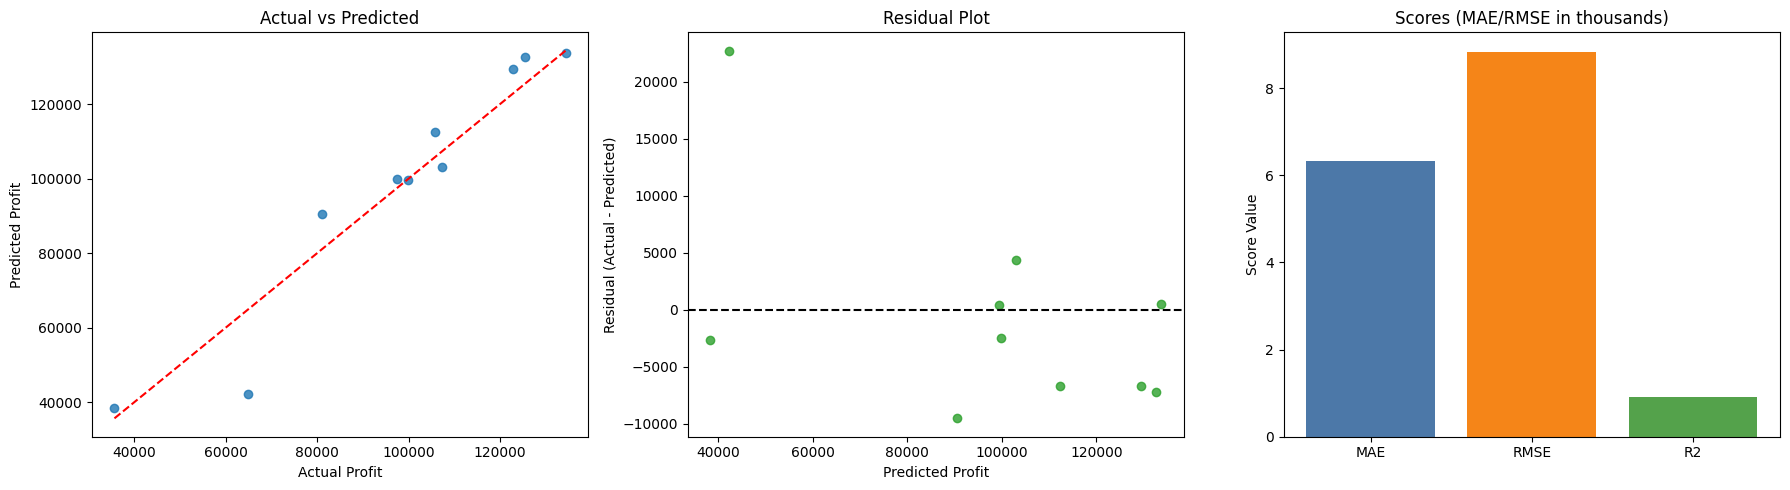

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Actual vs Predicted
axes[0].scatter(y_test, y_pred, color='tab:blue', alpha=0.8)
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], 'r--')
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Profit')
axes[0].set_ylabel('Predicted Profit')

# 2) Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, color='tab:green', alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Profit')
axes[1].set_ylabel('Residual (Actual - Predicted)')

# 3) Score bar chart
plot_scores = scores_df.copy()
mae_rmse_mask = plot_scores['Metric'].isin(['MAE', 'RMSE'])
plot_scores.loc[mae_rmse_mask, 'Value'] = plot_scores.loc[mae_rmse_mask, 'Value'] / 1000
axes[2].bar(plot_scores['Metric'], plot_scores['Value'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[2].set_title('Scores (MAE/RMSE in thousands)')
axes[2].set_ylabel('Score Value')

plt.tight_layout()
plt.show()

## Step 8: Feature Importance

,Feature,Importance
0,num__R&D Spend,0.932902
2,num__Marketing Spend,0.061277
1,num__Administration,0.003546
3,cat__State_California,0.001577
4,cat__State_Florida,0.000425
5,cat__State_New York,0.000273


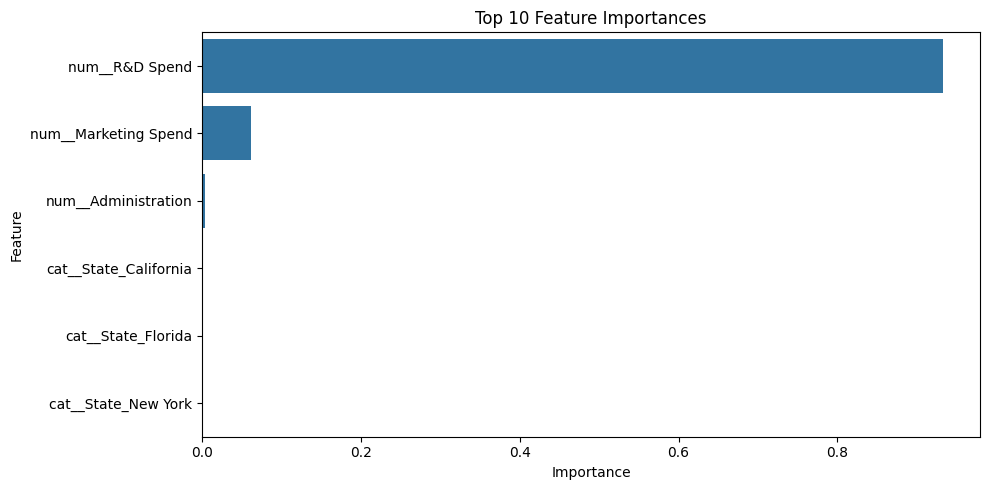

In [8]:
trained_forest = pipeline.named_steps['model']
trained_preprocessor = pipeline.named_steps['preprocessor']

feature_names = trained_preprocessor.get_feature_names_out()
importances = trained_forest.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

display(importance_df.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

## Step 9: Plot One Tree from the Forest
Random Forest has many trees. Here we plot one tree to understand split logic.

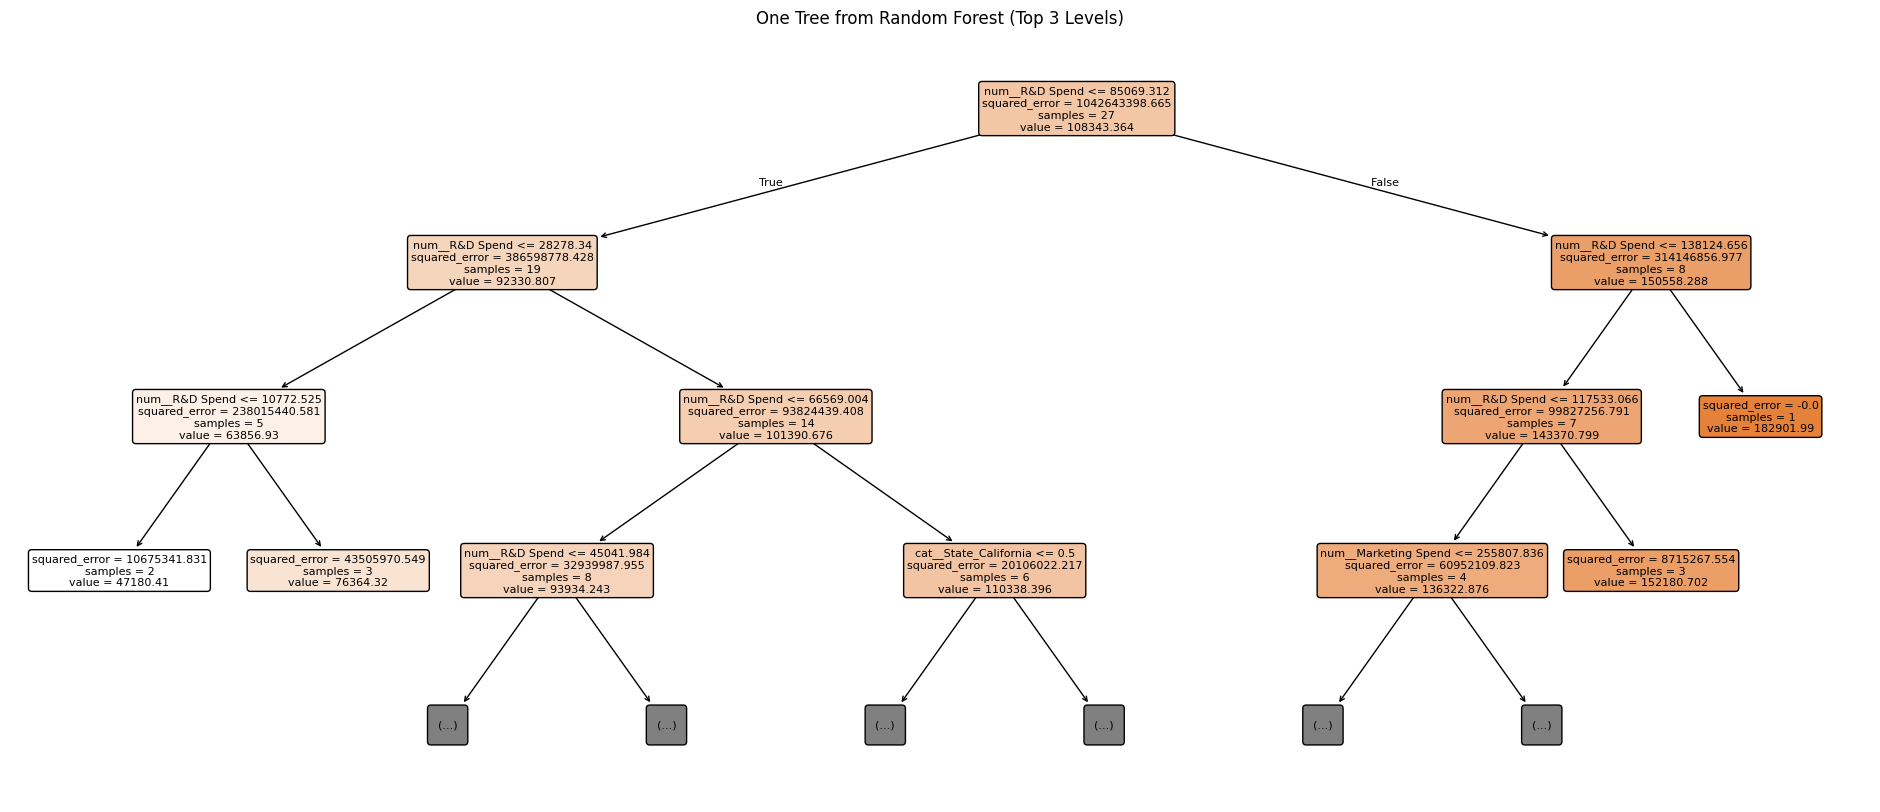

In [9]:
one_tree = trained_forest.estimators_[0]

plt.figure(figsize=(24, 10))
plot_tree(
    one_tree,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('One Tree from Random Forest (Top 3 Levels)')
plt.show()

## Simple English Summary
- Random Forest uses many trees and averages their predictions.
- Pipeline handled missing values and categorical encoding.
- MAE, RMSE, and R2 show prediction quality.
- Graphs make model behavior and errors easy to understand.